## Oppgave 6: Varmeligning,  (10 poeng)


### a)
Gjenstanden som skal brukes skal være et tverrsnitt av en gran/furu. Trevirke generelt ligger på en diffusivitet på:  $0.08 - 0.16\,\text{mm}^2/\text{s}$

Mens gran/Furu ligger i området: $0.13 - 0.14\,\text{mm}^2/\text{s}$

Velger derfor å bruke verdien: 
$$\alpha = 0.14\,\text{mm}^2/\text{s}$$

For å gjøre varmeplottene mer oversiktlig velger jeg å omskrive verdien $alpha$ slik at: 
$$\alpha = 0.084\,\text{cm}^2/\text{min}$$

Ønsker å vite hvordan diffusiviteten oppfører seg i en standard $48x98 {mm}$ konstruksjonsvirke. Velger å forenkle, slik at koordinatene som beskriver $x$ og $y$ er: 
$$-5 < x < 5,\; 0 < y < 5.$$
For $x$ og $y$ verdier i cm


### b)
Ser på differensiallikningen

$$
\begin{align}
u_t = \alpha\cdot(u_{xx} + u_{yy}), \quad -5<x<5, 0<y<5
\end{align}
$$

Bruker initialbetingelsene
$$\begin{align}u(x,y,0) = 15\end{align}$$

Og følgende randbetingelser:
$$
\begin{align}
u(-5,y,t) = 200, \quad & 0\leq y \leq 5 \\
u(5,y,t) = 200, \quad & 0\leq y \leq 5 \\
u(x,0,t) = 200, \quad & -5\leq x \leq 5 \\
u(x,5,t) = 200, \quad & -5 \leq x \leq 5
\end{align}
$$


Setter så opp den partielle differensialligningen som skal løses numerisk: 
$$
u(x,y,t+\Delta t)
=
u(x,y,t)
+
\alpha\,\Delta t
\left[
\frac{u(x-\Delta x, y, t) - 2u(x,y,t) + u(x+\Delta x, y, t)}{\Delta x^2}
+
\frac{u(x, y-\Delta y, t) - 2u(x,y,t) + u(x, y+\Delta y, t)}{\Delta y^2}
\right]
$$

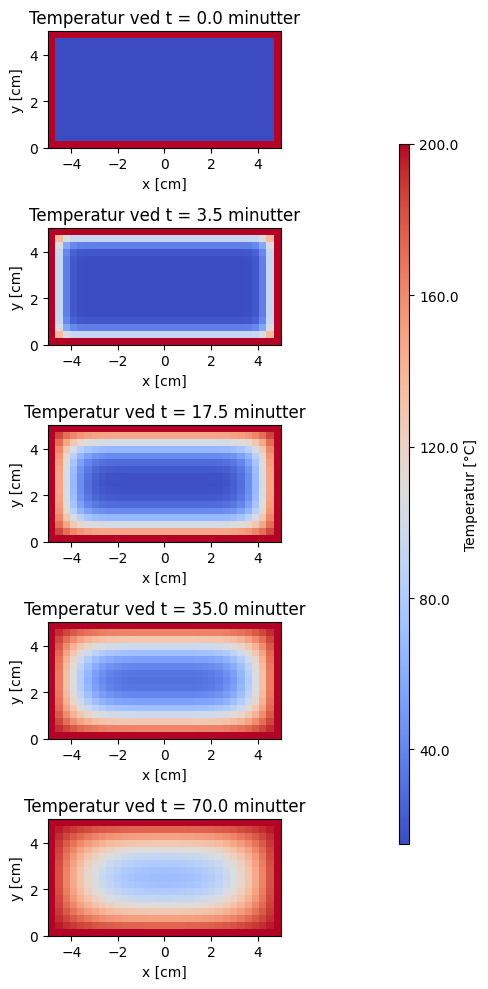
(bilde av oppgave 6 b) Varmeplot vedlegg) 


### c)

Her brukes det indeksering av matrise fra oppgave 6 b) for å finne tidsverdien når midten av legemet når 60 grader:
```python
ix_mid = m//2 + 1
iy_mid = n//2 + 1
T_mid = u[:, ix_mid, iy_mid]

# Finn første tidspunkt der temperaturen overstiger 60°C
idx_60 = np.argmax(T_mid >= 60)

# Tilsvarende tid i minutter
tid_60 = t[idx_60]
``` 

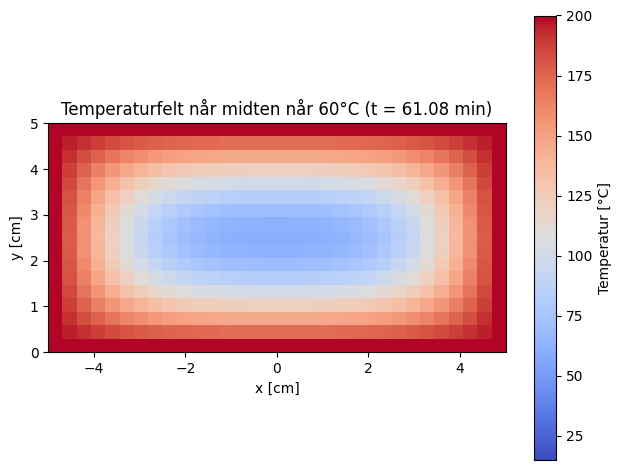
(Bilde Oppgave 6 c) varmeplott v. 60 grader) 

Temperaturen i midten av planken vi har valgt når 60 grader etter $61.08\ minutter$

### d)
Vi kan se ut ifra grafen at temperaturen endres raskt langs randen på "planken", men det tar veldig lang tid før det skjer temperaturendring ved kjernen. Dette er fordi det er valgt å bruke trevirke av type Furu. Dette materialet har relativt lav varmeledningsevne, og det trengs dermed lengre tid å transportere varme inn i materialet. 

(Henviser til GitHub repository med alt av kildekode til oppgave)

## Oppgave 7: Luften skal med (10 poeng)



### a)

Luft har en svært mye høyere varmeledningsevne enn trevirke, men dette er med forbehold om ren ledning av varme i luft(konveksjon), noe som ikke er realistisk. For å kompensere for dette og andre faktorer som ikke er tatt med, velges det å bruke verdien:

$$\alpha_{luft} = 0.5\,\text{cm}^2/\text{min}$$

Når luftlagaet skal med, velges jeg å først sette opp nye rand- og initialbetingelser for luftlaget: 

Initialbetingelser for luftlaget ved $t=0$: 

$$\begin{align}u(x,y,0) = 200\end{align}$$

Randbetingelser for luftlaget er:
$$
\begin{align}
u2(-10,y,t) = 200, \quad & -2.5\leq y \leq 7.5 \\
u2(10,y,t) = 200, \quad & -2.5\leq y \leq 7.5 \\
u2(x,-2.5,t) = 200, \quad & -10\leq x \leq 10 \\
u2(x,7.5,t) = 200, \quad & -10 \leq x \leq 10
\end{align}
$$

I tillegg legges det inn initialbetingelser i luftlaget hvor "planken" møter luften: 
$$
\begin{align}
u2((-5,5),(0,5),0) = 15, \quad & -2.5\leq y \leq 7.5 \\
u2(-5,[0,5],0) = 15, \quad & -2.5\leq y \leq 7.5 \\
u2(5,[0,5],0) = 15, \quad & -2.5\leq y \leq 7.5 \\
u2([-5,5],0,0) = 15, \quad & -10\leq x \leq 10 \\
u2([-5,5],5,0) = 15, \quad & -10 \leq x \leq 10
\end{align}
$$

Nå Befinner "planken" seg inni luftlaget, og har ikke lenger samme randbetingelse som fra oppgave 6. Randbetingelsene til planken er nå avhengig av temperaturen til luften rundt for hvert tidspunkt $t$. Initialbetingelsen for planken er fortsatt den samme som i oppgave 6. 
$$
\begin{align}
u(-5,y,t) = u2(-5,[0,5],t), \quad & 0\leq y \leq 5 \\
u(5,y,t) = u2(5,[0,5],t), \quad & 0\leq y \leq 5 \\
u(x,0,t) = u2([-5,5],0,t), \quad & -5\leq x \leq 5 \\
u(x,5,t) = u2([-5,5],5,t), \quad & -5 \leq x \leq 5
\end{align}
$$


MERK: Noe å tenke på her er at randbetingelsene til planken burde ha med et varmeovergangstall som beskriver hvordan temperaturen overføres mellom disse to forskjellige materialene. Uten dette vil det være en "perfekt kontakt" mellom luft og og tre. Dette vil føre til raskere oppvarming av planken enn hva som er fysisk mulig. 

Løser så dette numerisk ved hjelp av samme partielle differensiallikning som i oppgave 6 både for luften og for planken, men med mye rand- og initialbetingelser for planken. 

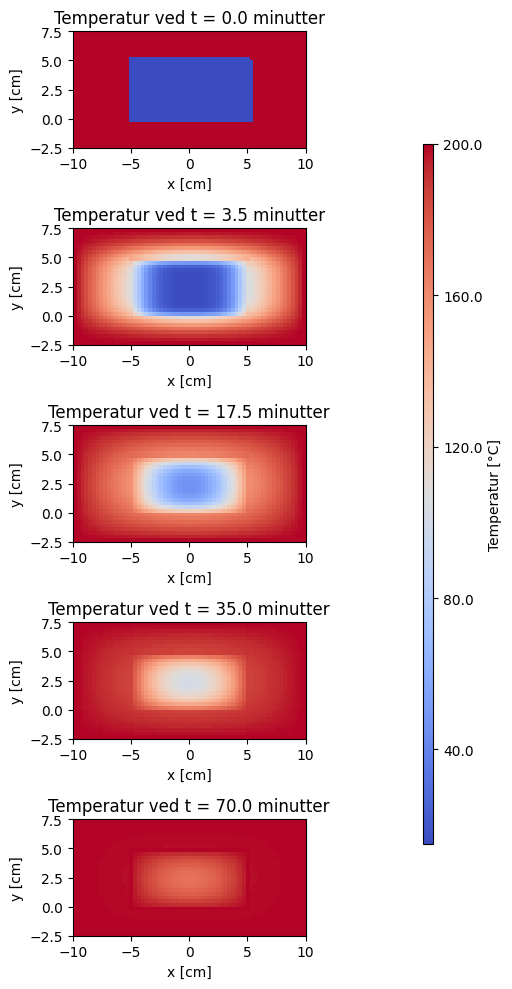 (Vedlegg oppgave 7 a) varmeplott) 



### b) 

(Henviser til GitHub repository for kildekode av animasjon)

Vi ser fra animasjonen av luften rundt planken synker fort i temperatur i starten, men stabiliserer seg etterhvert som tiden går. Her ser man at fordi det mangler et varmeovergangstall i randbetingelsene for overgangen mellom luft og tre, så fører dette til raskere endring i temperatur enn hva som er realisitisk i en slik situasjon. Dette forklarer også hvorfor planken faktisk blir varmet opp fortere enn når den ikke hadde et luftlag rundt seg i oppgave 6. 

### c) 

Bruker samme metode som i oppgave 6 og indekserer midten av arrayet, for å så finne ut ved hvilken tidsverdi som gir 60 grader. 

Planken når 60°C i midten etter ca. 21.79 minutter.

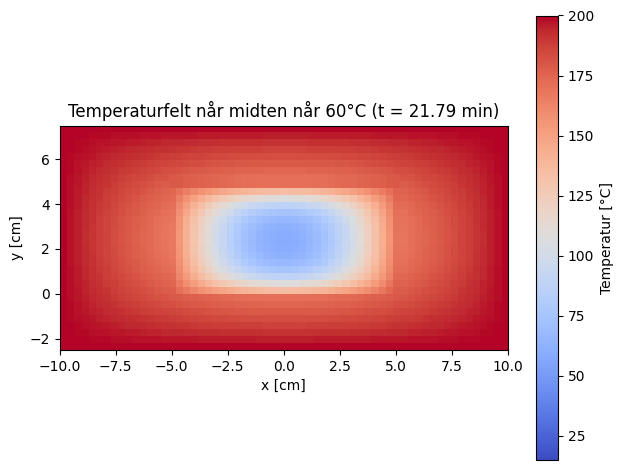 (Vedlegg oppgave 7 c) varmeplot for 60 grader med luft) 